In [1]:
%matplotlib inline

In [2]:
import random
import re
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader

from anomalib import TaskType
from anomalib.data import Folder, PredictDataset
from anomalib.engine import Engine
from anomalib.models import Patchcore

In [3]:
DATA = Path("data/bolt_roi")
IMAGE_SIZE = (256, 720)
SEED = 0

# explicit Resize+Normalize only, no crop. PatchCore's configure_transforms() default
# silently adds a CenterCrop that discards part of the ROI. Pass this explicitly instead.
from torchvision.transforms import v2
TRANSFORM = v2.Compose([
    v2.Resize(IMAGE_SIZE, antialias=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = Path("results/bolt_patchcore") / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR

WindowsPath('results/bolt_patchcore/20260831_162829')

In [4]:
random.seed(SEED)
torch.manual_seed(SEED)

datamodule = Folder(
    name="bolt",
    normal_dir=DATA / "train",
    task=TaskType.CLASSIFICATION,
    train_batch_size=8,
    eval_batch_size=8,
    num_workers=0,
    image_size=IMAGE_SIZE,
    transform=TRANSFORM,
    test_split_mode="none",
    val_split_mode="none",
)

model = Patchcore(
    backbone="resnet18",
    layers=["layer2", "layer3"],
    coreset_sampling_ratio=0.02,
)

engine = Engine(
    max_epochs=1,
    accelerator="auto",
    normalization="none",
    default_root_dir=str(OUT_DIR),
    logger=False,
    limit_val_batches=0,
    enable_progress_bar=False,
    enable_model_summary=False,
)

In [5]:
engine.fit(model=model, datamodule=datamodule)

ckpt_path = next(OUT_DIR.rglob("*.ckpt"))
print(f"checkpoint: {ckpt_path}")

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


You are using a CUDA device ('NVIDIA GeForce RTX 3080') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


...

Selecting Coreset Indices.:  99%|█████████▉| 8079/8121 [00:32<00:00, 248.07it/s]

Selecting Coreset Indices.: 100%|█████████▉| 8105/8121 [00:32<00:00, 250.07it/s]

Selecting Coreset Indices.: 100%|██████████| 8121/8121 [00:32<00:00, 251.67it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.


checkpoint: results\bolt_patchcore\20260831_162829\Patchcore\bolt\v0\weights\lightning\model.ckpt


In [6]:
def part_id_from_filename(path: Path) -> str:
    m = re.search(r"_p(\d+)_", path.name)
    return f"p{m.group(1)}" if m else path.stem


def score_folder(folder: Path) -> pd.DataFrame:
    dataset = PredictDataset(path=folder, image_size=IMAGE_SIZE)
    loader = DataLoader(dataset, batch_size=8, num_workers=0)
    predictions = engine.predict(model=model, dataloaders=loader)

    rows = []
    for batch in predictions:
        for path, score in zip(batch["image_path"], batch["pred_scores"]):
            p = Path(path)
            rows.append({"file": p.name, "part_id": part_id_from_filename(p), "score": float(score)})
    return pd.DataFrame(rows)

In [7]:
scores_heldout = score_folder(DATA / "heldout")
scores_surface = score_folder(DATA / "defects" / "surface")
scores_thread = score_folder(DATA / "defects" / "thread")

scores_heldout["group"] = "heldout (normal)"
scores_surface["group"] = "surface defect"
scores_thread["group"] = "thread defect"

scores_heldout.to_csv(OUT_DIR / "scores_heldout.csv", index=False)
scores_surface.to_csv(OUT_DIR / "scores_defects_surface.csv", index=False)
scores_thread.to_csv(OUT_DIR / "scores_defects_thread.csv", index=False)

def auroc(normal_scores, defect_scores):
    y = [0] * len(normal_scores) + [1] * len(defect_scores)
    s = list(normal_scores) + list(defect_scores)
    return roc_auc_score(y, s)

print(f"heldout: {len(scores_heldout)} frames / {scores_heldout.part_id.nunique()} parts")
print(f"surface: {len(scores_surface)} frames / {scores_surface.part_id.nunique()} parts   "
      f"AUROC={auroc(scores_heldout.score, scores_surface.score):.3f}")
print(f"thread:  {len(scores_thread)} frames / {scores_thread.part_id.nunique()} parts   "
      f"AUROC={auroc(scores_heldout.score, scores_thread.score):.3f}")

ckpt_path is not provided. Model weights will not be loaded.


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


C:\miniconda3\envs\aio\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


...

ckpt_path is not provided. Model weights will not be loaded.


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


heldout: 48 frames / 24 parts
surface: 41 frames / 14 parts   AUROC=0.988
thread:  39 frames / 13 parts   AUROC=0.819


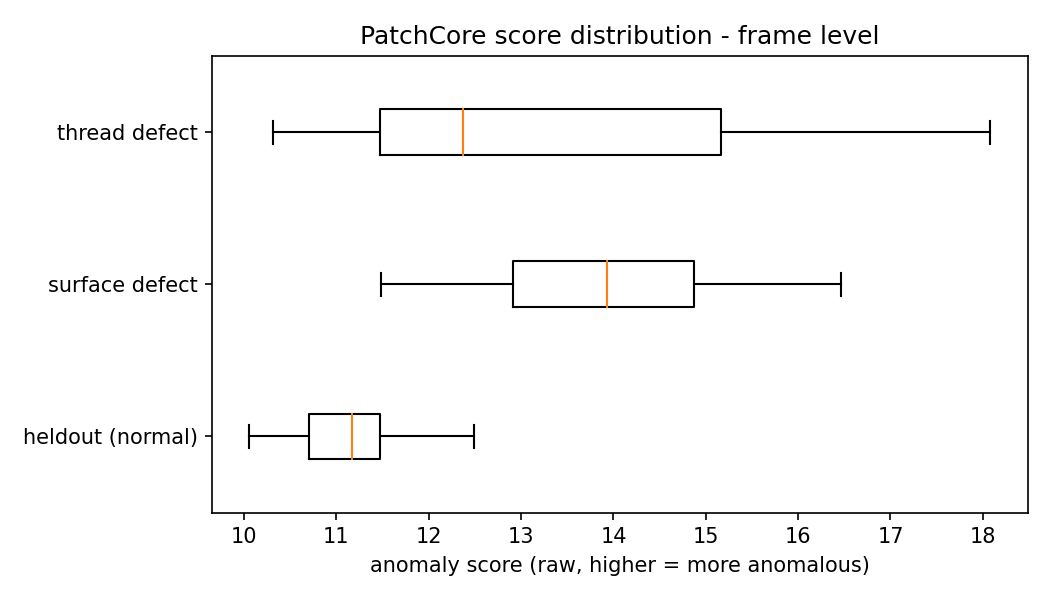

In [8]:
from IPython.display import Image, display

groups = ["heldout (normal)", "surface defect", "thread defect"]
data = [scores_heldout.score, scores_surface.score, scores_thread.score]

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(data, labels=groups, vert=False)
ax.set_xlabel("anomaly score (raw, higher = more anomalous)")
ax.set_title("PatchCore score distribution - frame level")

plt.tight_layout()
chart_path = OUT_DIR / "score_distribution.png"
plt.savefig(chart_path, dpi=150)
plt.close(fig)
display(Image(filename=str(chart_path)))

In [9]:
heldout_part = scores_heldout.groupby("part_id").score.max()
surface_part = scores_surface.groupby("part_id").score.max()
thread_part = scores_thread.groupby("part_id").score.max()

candidates = np.sort(np.concatenate([heldout_part.values, surface_part.values, thread_part.values]))
sweep = []
for thr in candidates:
    fpr = (heldout_part > thr).mean()
    recall_surface = (surface_part > thr).mean()
    recall_thread = (thread_part > thr).mean()
    sweep.append({"threshold": thr, "heldout_fpr": fpr,
                  "recall_surface": recall_surface, "recall_thread": recall_thread})
sweep = pd.DataFrame(sweep)
sweep.head()

,threshold,heldout_fpr,recall_surface,recall_thread
0,10.271348,0.958333,1.0,1.0
1,10.611608,0.916667,1.0,1.0
2,10.678005,0.875000,1.0,1.0
3,10.725805,0.833333,1.0,1.0
4,10.733831,0.791667,1.0,1.0


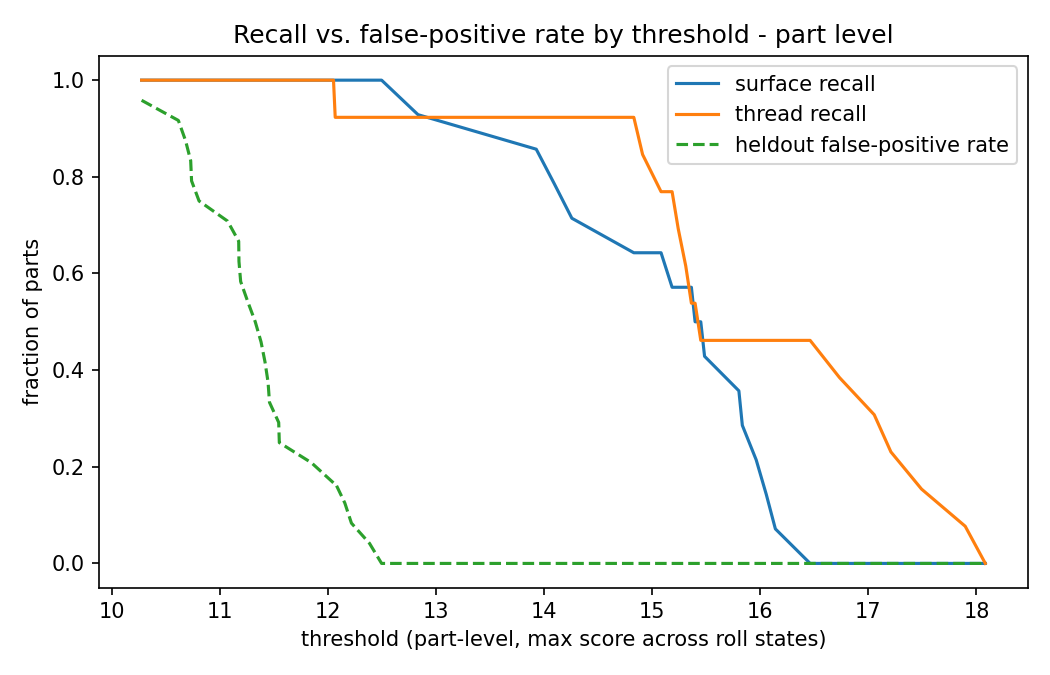

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(sweep.threshold, sweep.recall_surface, label="surface recall")
ax.plot(sweep.threshold, sweep.recall_thread, label="thread recall")
ax.plot(sweep.threshold, sweep.heldout_fpr, label="heldout false-positive rate", linestyle="--")

ax.set_xlabel("threshold (part-level, max score across roll states)")
ax.set_ylabel("fraction of parts")
ax.set_title("Recall vs. false-positive rate by threshold - part level")
ax.legend()

plt.tight_layout()
chart_path = OUT_DIR / "threshold_sweep.png"
plt.savefig(chart_path, dpi=150)
plt.close(fig)
display(Image(filename=str(chart_path)))

In [11]:
# recall-biased pick: lowest threshold that keeps heldout FPR <= 1 part in 24 (~4%)
MAX_ACCEPTABLE_FPR = 1 / len(heldout_part)
feasible = sweep[sweep.heldout_fpr <= MAX_ACCEPTABLE_FPR]
CHOSEN_THRESHOLD = float(feasible.threshold.min())

chosen_row = sweep[sweep.threshold == CHOSEN_THRESHOLD].iloc[0]
n_fp = int(round(chosen_row.heldout_fpr * len(heldout_part)))
n_surface_caught = int(round(chosen_row.recall_surface * len(surface_part)))
n_thread_caught = int(round(chosen_row.recall_thread * len(thread_part)))

print(f"chosen threshold: {CHOSEN_THRESHOLD:.2f}")
print(f"heldout false positives: {n_fp} / {len(heldout_part)} normal parts flagged")
print(f"surface defects caught:  {n_surface_caught} / {len(surface_part)} parts "
      f"({chosen_row.recall_surface:.0%} recall)")
print(f"thread defects caught:   {n_thread_caught} / {len(thread_part)} parts "
      f"({chosen_row.recall_thread:.0%} recall)")
print(f"\nnote: {len(heldout_part)} heldout parts means each FP step is ~{1/len(heldout_part):.1%} FPR "
      f"resolution, this is not a fine-grained estimate.")

chosen threshold: 12.38
heldout false positives: 1 / 24 normal parts flagged
surface defects caught:  14 / 14 parts (100% recall)
thread defects caught:   12 / 13 parts (92% recall)

note: 24 heldout parts means each FP step is ~4.2% FPR resolution, this is not a fine-grained estimate.


ckpt_path is not provided. Model weights will not be loaded.


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


C:\miniconda3\envs\aio\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


ckpt_path is not provided. Model weights will not be loaded.


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


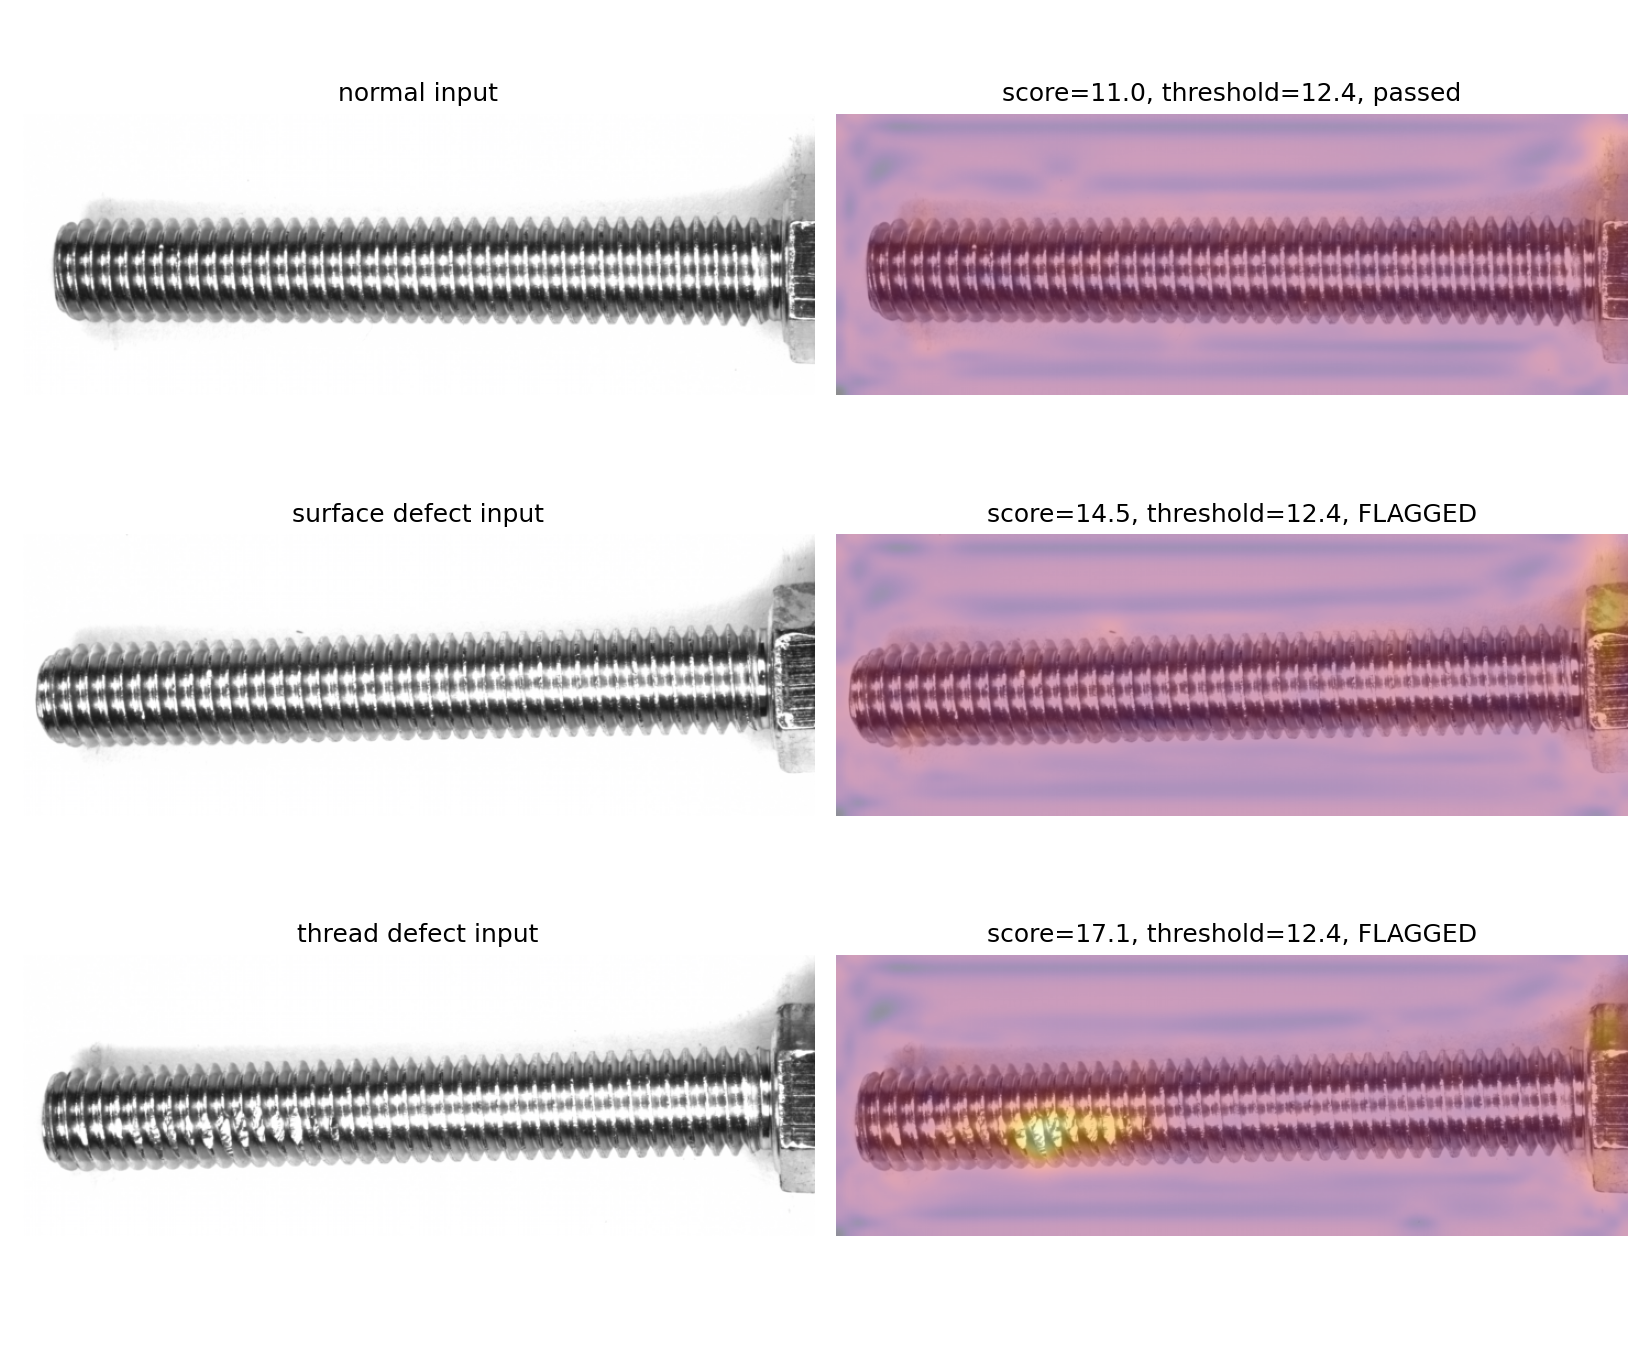

In [12]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def denormalize(img_tensor):
    img = img_tensor.cpu() * IMAGENET_STD + IMAGENET_MEAN
    return img.clamp(0, 1).permute(1, 2, 0).numpy()


def predict_one(image_path):
    dataset = PredictDataset(path=image_path, image_size=IMAGE_SIZE)
    loader = DataLoader(dataset, batch_size=1, num_workers=0)
    batch = engine.predict(model=model, dataloaders=loader)[0]
    return batch["image"][0], batch["anomaly_maps"][0].squeeze(), float(batch["pred_scores"][0])


examples = [
    ("normal", DATA / "heldout" / "bolt_normal_heldout_p23_r1_A.png"),
    ("surface defect", DATA / "defects" / "surface" / "bolt_defect_surface_p12_r1_A.png"),
    ("thread defect", DATA / "defects" / "thread" / "bolt_defect_thread_p03_r1_A.png"),
]

results_ = [predict_one(path) for _, path in examples]
maps = [m.detach().numpy() for _, m, _ in results_]
vmin, vmax = min(m.min() for m in maps), max(m.max() for m in maps)

fig, axes = plt.subplots(len(examples), 2, figsize=(11, 3 * len(examples)))

for r, ((label, path), (img_t, map_t, score)) in enumerate(zip(examples, results_)):
    img = denormalize(img_t)
    flagged = "FLAGGED" if score > CHOSEN_THRESHOLD else "passed"

    axes[r, 0].imshow(img)
    axes[r, 0].set_title(f"{label} input")
    axes[r, 0].axis("off")

    axes[r, 1].imshow(img)
    axes[r, 1].imshow(map_t.detach().numpy(), cmap="inferno", alpha=0.45, vmin=vmin, vmax=vmax)
    axes[r, 1].set_title(f"score={score:.1f}, threshold={CHOSEN_THRESHOLD:.1f}, {flagged}")
    axes[r, 1].axis("off")

plt.tight_layout()
chart_path = OUT_DIR / "example_predictions.png"
plt.savefig(chart_path, dpi=150)
plt.close(fig)
display(Image(filename=str(chart_path)))